### Re-uploading the `KDDTest+.arff` file

If your Colab runtime restarts or the file is no longer present, you can use the following cell to upload the `KDDTest+.arff` file again from your local computer. A file selection dialog will appear after running this cell.

In [2]:
from google.colab import files
import os
import pandas as pd


# Upload the file from your local machine
print("Please upload the 'KDDTest+.arff' file:")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
# Assuming only one file is uploaded, we take the first key
if uploaded:
    for filename in uploaded.keys():
        print(f'User uploaded file: {filename}')
        # Move the uploaded file to /content/ for consistent access
        if not os.path.exists(f'/content/{filename}'):
            os.rename(filename, f'/content/{filename}')
        file_path = f'/content/{filename}'
else:
    print("No file was uploaded.")
    # Set file_path to None or handle as an error if no file was uploaded
    file_path = None

# Define the column names ourselves (standard NSL-KDD feature order)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
]

# Only proceed if a file was successfully uploaded
if file_path:
    # Read the file, find where @data starts, then read everything after it as CSV
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data_start = next(i for i, line in enumerate(lines) if line.strip().lower() == '@data') + 1

    from io import StringIO
    data_str = ''.join(lines[data_start:])
    df = pd.read_csv(StringIO(data_str), header=None, names=columns)

    print("File successfully loaded into DataFrame. Displaying head:")
    display(df.head())
else:
    print("Cannot load DataFrame as no file was uploaded.")

Please upload the 'KDDTest+.arff' file:


Saving KDDTest+.arff to KDDTest+.arff
User uploaded file: KDDTest+.arff
File successfully loaded into DataFrame. Displaying head:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


In [3]:
df.shape

(22544, 42)

In [4]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [6]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [7]:
df['class'].value_counts()

,count
class,
anomaly,12833
normal,9711


In [8]:
df["protocol_type"].value_counts()

,count
protocol_type,
tcp,18880
udp,2621
icmp,1043


In [9]:
df["service"].value_counts()

,count
service,
http,7853
private,4774
telnet,1626
pop_3,1019
smtp,934
...,...
printer,11
ntp_u,10
rje,8


In [10]:
print(df["flag"].value_counts())

flag
SF        14875
REJ        3850
S0         2013
RSTO        773
RSTR        669
S3          249
SH           73
S1           21
S2           15
OTH           4
RSTOS0        2
Name: count, dtype: int64


In [11]:
X = df.drop('class',axis=1)
y = df["class"]

In [12]:
y = y.map({'normal':0, 'anomaly':1})

In [13]:
X = pd.get_dummies(X, columns=['protocol_type', 'service', 'flag'])


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X.shape

(22544, 116)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.2, random_state=42, stratify = y)

In [17]:
from sklearn.linear_model import LogisticRegression
lg_regression = LogisticRegression(max_iter=1000, random_state=42)
lg_regression.fit(X_train, y_train)
lg_pred = lg_regression.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_pred = rf_classifier.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score
precision = precision_score
recall = recall_score
f1 = f1_score
conf_matrix = confusion_matrix
class_report = classification_report
print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy(y_test, lg_pred)}")
print(f"Precision: {precision(y_test, lg_pred)}")
print(f"Recall: {recall(y_test, lg_pred)}")
print(f"F1 Score: {f1(y_test, lg_pred)}")
print("Confusion Matrix:")
print(conf_matrix(y_test, lg_pred))
print("Classification Report:")
print(class_report(y_test, lg_pred))

print("Random Forest Metrics:")
print(f"Accuracy: {accuracy(y_test, rf_pred)}")
print(f"Precision: {precision(y_test, rf_pred)}")
print(f"Recall: {recall(y_test, rf_pred)}")
print(f"F1 Score: {f1(y_test, rf_pred)}")
print("Confusion Matrix:")
print(conf_matrix(y_test, rf_pred))
print("Classification Report:")
print(class_report(y_test, rf_pred))

Logistic Regression Metrics:
Accuracy: 0.9536482590374806
Precision: 0.9524174980813507
Recall: 0.9668874172185431
F1 Score: 0.9595979122366132
Confusion Matrix:
[[1818  124]
 [  85 2482]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1942
           1       0.95      0.97      0.96      2567

    accuracy                           0.95      4509
   macro avg       0.95      0.95      0.95      4509
weighted avg       0.95      0.95      0.95      4509

Random Forest Metrics:
Accuracy: 0.9882457307607008
Precision: 0.990632318501171
Recall: 0.9887027658745617
F1 Score: 0.9896666016767401
Confusion Matrix:
[[1918   24]
 [  29 2538]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99     

In [20]:
importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)
print(top_features)

src_bytes                      0.131411
dst_bytes                      0.100113
service_http                   0.060580
dst_host_diff_srv_rate         0.059535
dst_host_rerror_rate           0.050371
flag_SF                        0.048883
dst_host_same_srv_rate         0.044709
dst_host_srv_count             0.044610
duration                       0.036334
dst_host_srv_rerror_rate       0.029885
dst_host_same_src_port_rate    0.027156
same_srv_rate                  0.025782
diff_srv_rate                  0.025540
srv_count                      0.024516
count                          0.023925
dtype: float64


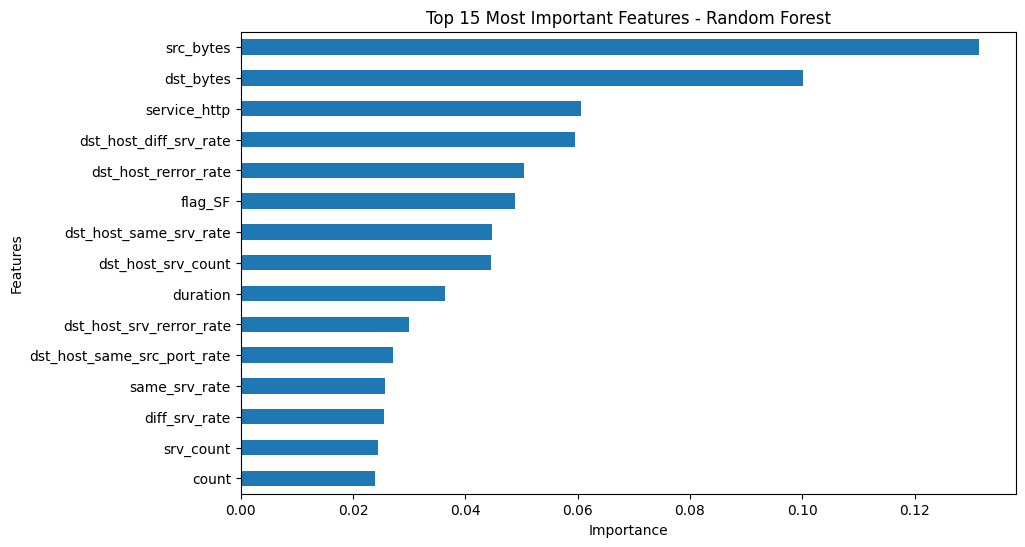

In [21]:
import matplotlib.pyplot as plt
top_features.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Top 15 Most Important Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [25]:
import joblib

joblib.dump(rf_classifier, 'rf_model.pkl')
joblib.dump(lg_regression, 'log_reg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

from google.colab import files
files.download('rf_model.pkl')
files.download('log_reg_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>